In [4]:
import sys
import gym

import sys

sys.path.append(r"C:\Users\admin\Downloads\inferself-main\src")
import gym_gridworld.envs
from gym_gridworld.envs.gridworld_env import GridworldEnv
from inferself_code import InferSelf
env = gym.make("changeAgent_u-7-v0")

_ = env.reset()          # just initializes the env
obs = env.get_obs_state()  # semantic observation for InferSelf
from play_and_infer import ARGS
from inferself_code import InferSelf

agent = InferSelf(obs, ARGS)

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


change_agent_u


C:\Users\admin\.conda\envs\mepomdp\lib\site-packages\gym\utils\passive_env_checker.py:20: UserWarning: WARN: It seems a Box observation space is an image but the `dtype` is not `np.uint8`, actual type: float32. If the Box observation space is not an image, we recommend flattening the observation to have only a 1D vector.
  logger.warn(
C:\Users\admin\.conda\envs\mepomdp\lib\site-packages\gym\utils\passive_env_checker.py:25: UserWarning: WARN: It seems a Box observation space is an image but the upper and lower bounds are not in [0, 255]. Generally, CNN policies assume observations are within that range, so you may encounter an issue if the observation values are not.
  logger.warn(
C:\Users\admin\.conda\envs\mepomdp\lib\site-packages\gym\core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
C:\Users\a

In [8]:
import numpy as np
import random
import pickle
import os
from copy import deepcopy
import gym
from inferself import InferSelf
from heuristic import Heuristic

In [15]:
def get_centering_step(run_data):
    """
    Returns first timestep where centering happens.
    If never centered, returns max_steps.
    """
    for step in run_data:
        if step['centered']:
            return step['t']
    return max_steps


In [22]:
means_base = []
means_limited = []
std_base = []
std_limited = []

for game in game_types:
    means_base.append(np.mean(results["base"][game]))
    std_base.append(np.std(results["base"][game]))

    means_limited.append(np.mean(results["limited"][game]))
    std_limited.append(np.std(results["limited"][game]))


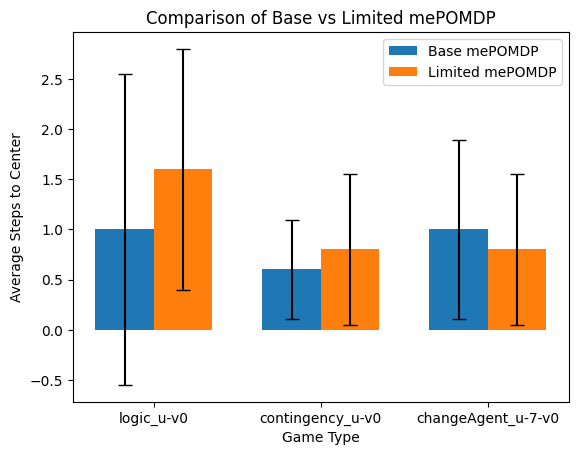

In [23]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(game_types))
width = 0.35

plt.figure()

plt.bar(x - width/2, means_base, width,
        yerr=std_base,
        capsize=5)

plt.bar(x + width/2, means_limited, width,
        yerr=std_limited,
        capsize=5)

plt.xticks(x, game_types)
plt.ylabel("Average Steps to Center")
plt.xlabel("Game Type")
plt.title("Comparison of Base vs Limited mePOMDP")

plt.legend(["Base mePOMDP", "Limited mePOMDP"])

plt.show()


In [21]:
#EXPERIMENT RUN FOR COLLECTING AVG NUMBER OF STEPS BEFORE CENTERING

import matplotlib.pyplot as plt

game_types = [
    'logic_u-v0',
    'contingency_u-v0',
    'changeAgent_u-7-v0'
]

n_runs = 5  # number of seeds per game

results = {
    "base": {game: [] for game in game_types},
    "limited": {game: [] for game in game_types}
}

for game in game_types:

    for seed in range(n_runs):

        np.random.seed(seed)
        random.seed(seed)

        # ----- Base agent -----
        data_base = run_agent_in_env(
            env_name=game,
            agent="base",
            threshold=threshold,
            ff=ff,
            attention_mode="full",
            max_steps=max_steps
        )

        results["base"][game].append(
            get_centering_step(data_base)
        )

        # ----- Limited agent -----
        data_limited = run_agent_in_env(
            env_name=game,
            agent="base",
            threshold=threshold,
            ff=ff,
            attention_mode="limited",
            max_steps=max_steps
        )

        results["limited"][game].append(
            get_centering_step(data_limited)
        )

logic_u
  explore
  Top theories:
    agent id:  2 , prob:  0.49874 p_switch: 0.01
    agent id:  3 , prob:  0.49874 p_switch: 0.01
    agent id:  0 , prob:  0.00126 p_switch: 0.01
    agent id:  1 , prob:  0.00126 p_switch: 0.01
  explore
  Top theories:
    agent id:  2 , prob:  0.5 p_switch: 0.01
    agent id:  3 , prob:  0.5 p_switch: 0.01
    agent id:  0 , prob:  0.0 p_switch: 0.01
    agent id:  0 , prob:  0.0 p_switch: 0.01
  explore
  Top theories:
    agent id:  2 , prob:  0.5 p_switch: 0.01
    agent id:  3 , prob:  0.5 p_switch: 0.01
    agent id:  0 , prob:  0.0 p_switch: 0.01
    agent id:  0 , prob:  0.0 p_switch: 0.01
  explore
  Top theories:
    agent id:  2 , prob:  0.5 p_switch: 0.01
    agent id:  3 , prob:  0.5 p_switch: 0.01
    agent id:  0 , prob:  0.0 p_switch: 0.01
    agent id:  0 , prob:  0.0 p_switch: 0.01
  explore and exploit
  Top theories:
    agent id:  2 , prob:  0.99937 p_switch: 0.01
    agent id:  3 , prob:  0.00063 p_switch: 0.01
    agent id:  0

In [28]:
#ORIGINAL LOOP FOR DEBUG RUN

import numpy as np
import random
import pickle
import os
from copy import deepcopy
import gym
from inferself import InferSelf
from heuristic import Heuristic

# -----------------------------
# Debug parameters
# -----------------------------
expe_name = "changeagenr_base_debug"
env_name = 'changeAgent_u-7-v0'
agent = 'base'
threshold = 1.5
ff = 0.4
n_seeds = 1
n_levels = 1
time_limit = 0
max_steps = 50
save_dir = "output/"

os.makedirs(save_dir, exist_ok=True)

# -----------------------------
# Arguments for agent
# -----------------------------
def get_args(env, agent, attention_mode='full'):
    args = dict(max_steps=2,
                infer_mapping=False,
                infer_switch=False,
                biased_action_mapping=False,
                biased_action_mapping_factor=10,
                bias_bot_mvt='uniform',
                p_switch=0.01,
                likelihood_weight=1,
                explicit_resetting=False,
                noise_prior=0.01,
                avatar_noise=0.01,
                explore_only=False,
                explore_randomly=False,
                simulation='sampling',
                n_simulations=1,
                uniform_attention_bias=False,
                attention_bias=False,
                mapping_forgetting_factor=None,
                forget_action_mapping=False,
                n_objs_attended_to=4,
                peripheral_attention_prob=0.05,
                heuristic_noise=0.1,
                is_heuristic=False,
                check_oob=False,
                conf_threshold=threshold,
                verbose=True,
                )

    # Add attention handling
    if attention_mode == "limited":
        args['uniform_attention_bias'] = True
        args['attention_bias'] = True
    else:
        args['uniform_attention_bias'] = False
        args['attention_bias'] = False

    return args


def safe_render(env):
    """
    Render environment safely across old/new gym versions.
    """
    base_env = unwrap_env(env)

    # If environment already has render()
    if hasattr(base_env, "render"):
        try:
            base_env.render(mode='human')
        except TypeError:
            try:
                base_env.render()
            except:
                pass

# -----------------------------
# Environment unwrapping helpers
# -----------------------------
def unwrap_env(env):
    """Recursively unwrap Gym environment to get the original environment."""
    unwrapped = env
    while hasattr(unwrapped, 'env'):
        unwrapped = unwrapped.env
    while hasattr(unwrapped, 'unwrapped'):
        unwrapped = unwrapped.unwrapped
    return unwrapped

def get_obs_state(env):
    """
    Return the semantic state (dictionary) from the environment,
    containing 'objects' positions and 'map'.
    """
    env = unwrap_env(env)

    # If environment provides get_obs_state
    if hasattr(env, 'get_obs_state'):
        return env.get_obs_state()

    # Otherwise, try to construct manually from env
    obs_state = {}
    if hasattr(env, 'semantic_state'):
        obs_state['objects'] = getattr(env.semantic_state, 'objects', None)
        obs_state['map'] = getattr(env.semantic_state, 'map', None)
    else:
        # fallback if semantic_state not available
        last_obs = getattr(env, 'last_obs', None)
        if last_obs is not None and isinstance(last_obs, (tuple, list)):
            obs_state['objects'] = last_obs[0]
            obs_state['map'] = last_obs[1]
        else:
            obs_state['objects'] = None
            obs_state['map'] = None
    return obs_state

# -----------------------------
# Compute prob of true theory
# -----------------------------
def get_prob_of_true(s, true_agent, true_mapping):
    for i_theory, theory in enumerate(s.theories):
        found_it = False
        if theory['agent_id'] == true_agent:
            found_it = True
            for i, d in enumerate(true_mapping):
                if np.any(theory['input_mapping'][i] != d):
                    found_it = False
        if found_it:
            return s.current_posterior_over_theories[i_theory], s.get_noise_mean(s.theories[i_theory])

# -----------------------------
# Run agent in environment
# -----------------------------
def run_agent_in_env(env_name, agent, threshold, ff, attention_mode="full", max_steps=50):
    args = get_args(env_name, agent, attention_mode)
    args['conf_threshold'] = threshold
    args['mapping_forgetting_factor'] = ff

    env = gym.make(env_name)

    
    # Original env reset to get semantic obs_state
    prev_obs, prev_info, prev_obs_state = env.reset()
    args.update(n_objs=env.n_candidates)


    # Choose InferSelf or Heuristic
    if 'heuristic' in agent:
        inferself = Heuristic(obs=prev_obs_state, args=args)
    else:
        inferself = InferSelf(obs=prev_obs_state, args=args)

    previous_agent = None
    data = []
    t=0
    done=False
    while not done and t < max_steps:
        # get action
        action, _ = inferself.get_action(prev_obs_state)

        # step in env (Gym 0.26+)
        step_result = env.step(action)
        if len(step_result) == 4:
            obs, rew, info, obs_state = step_result
        elif len(step_result) == 5:
            obs, rew, terminated, truncated, info, obs_state = step_result
        else:
            raise ValueError("Unexpected step_result length:", len(step_result))
        #if len(step_result) == 5:
          #  obs, rew, terminated, truncated, info = step_result
         #   done = terminated or truncated

        # Convert 'objects' to a 2D array for InferSelf
        obs_state_fixed = obs_state.copy()
        obs_state_fixed['objects'] = np.array(obs_state['objects'])


        # update theory
        inferself.update_theory(prev_obs_state, obs_state_fixed, action)
        prev_obs_state = obs_state_fixed

        posterior = inferself.current_posterior_over_theories
        sorted_post = np.sort(posterior)[::-1]

        centered = False
        if len(sorted_post) > 1:
            ratio = sorted_post[0] / (sorted_post[1] + 1e-8)
            if ratio > threshold:
                centered = True
            #print(f"🔥 THEORY CENTERED at step {t}")

        #AVATAR IDENTIFICATION DETECTION
        identified = False
        top_index = np.argmax(posterior)
        top_theory = inferself.theories[top_index]

        if top_theory['agent_id'] == env.unwrapped.agent_id:
            identified = True


        # Get indices of theories sorted by posterior probability (descending)
        sorted_indices = np.argsort(inferself.current_posterior_over_theories)[::-1]

# Pick the top 2 theories
        top_theories = [inferself.theories[i] for i in sorted_indices[:2]]

# Print action-direction mapping for top 2 theories
        #for rank, theory in enumerate(top_theories, start=1):
            #print(f"Step {t}: Top {rank} theory -> agent_id: {theory['agent_id']}")
            #print("  Action-direction mapping:")
            #for action_idx, direction in enumerate(theory['input_mapping']):
             #   print(f"    Action {action_idx} -> {direction}")

        # Print observed map
        #print("Observed map after this step:")
        #print(obs_state_fixed['map'])
                
        # track agent change
        change = previous_agent != env.unwrapped.agent_id
        previous_agent = env.unwrapped.agent_id

        # safe access to success
        success_flag = False
        if isinstance(info, dict):
            success_flag = info.get('success', False)
        elif isinstance(info, bool):
            success_flag = info

        # save step data
        data.append({
            't': t,
            'action': action,
            'success': success_flag,
            'agent_id': env.unwrapped.agent_id,
            'agent_changed': change,
            'obj_pos': obs_state.get('objects', None),
            'map': obs_state.get('map', None),
            'centered': centered,
            'identified': identified
        })

        # stop if goal reached
        if success_flag:
            done = True

        t += 1

    return data

# -----------------------------
# Run debug experiment
# -----------------------------
#np.random.seed(0)
#random.seed(0)

#base mePOMDP
#debug_data = run_agent_in_env(env_name, agent, threshold, ff,  attention_mode="full", max_steps=max_steps)
#replay_debug_data(debug_data, delay=0.5)

# LIMITED mePOMDP
#data_limited = run_agent_in_env(
    #env_name=env_name,
   # agent="base",
  #  threshold=threshold,
 #   ff=ff,
#    attention_mode="limited",
#    max_steps=max_steps
#)


# Print summary
#print("Debug run finished!")
#print(f"Total steps taken: {len(debug_data)}")
#print("Actions taken:", [d['action'] for d in debug_data])
#print("Success flags:", [d['success'] for d in debug_data])
#print("Agent IDs:", [d['agent_id'] for d in debug_data])

# Save debug data
#data_path = os.path.join(save_dir, f"{expe_name}.pkl")
#with open(data_path, 'wb') as f:
#    pickle.dump(debug_data, f)

#print(f"Debug data saved to {data_path}")


In [32]:
import numpy as np
import random

game_types = [
    'logic_u-v0',
    'contingency_u-v0',
    'changeAgent_u-7-v0'
]

n_runs = 5
results = {
    "base": {
        game: {"before": [], "after": [], "total": []}
        for game in game_types
    },
    "limited": {
        game: {"before": [], "after": [], "total": []}
        for game in game_types
    }
}
for game in game_types:

    for seed in range(n_runs):

        np.random.seed(seed)
        random.seed(seed)

        # ---------------- Base ----------------
        data_base = run_agent_in_env(
            env_name=game,
            agent="base",
            threshold=threshold,
            ff=ff,
            attention_mode="full",
            max_steps=max_steps
        )

        center_step = get_centering_step(data_base)
        total_steps = len(data_base)   # <-- important fix

        results["base"][game]["before"].append(center_step)
        results["base"][game]["after"].append(total_steps - center_step)
        results["base"][game]["total"].append(total_steps)

        # ---------------- Limited ----------------
        data_limited = run_agent_in_env(
            env_name=game,
            agent="base",
            threshold=threshold,
            ff=ff,
            attention_mode="limited",
            max_steps=max_steps
        )

        center_step = get_centering_step(data_limited)
        total_steps = len(data_limited)

        results["limited"][game]["before"].append(center_step)
        results["limited"][game]["after"].append(total_steps - center_step)
        results["limited"][game]["total"].append(total_steps)


logic_u
  explore
  Top theories:
    agent id:  2 , prob:  0.49874 p_switch: 0.01
    agent id:  3 , prob:  0.49874 p_switch: 0.01
    agent id:  0 , prob:  0.00126 p_switch: 0.01
    agent id:  1 , prob:  0.00126 p_switch: 0.01
  explore
  Top theories:
    agent id:  2 , prob:  0.5 p_switch: 0.01
    agent id:  3 , prob:  0.5 p_switch: 0.01
    agent id:  0 , prob:  0.0 p_switch: 0.01
    agent id:  0 , prob:  0.0 p_switch: 0.01
  explore
  Top theories:
    agent id:  2 , prob:  0.5 p_switch: 0.01
    agent id:  3 , prob:  0.5 p_switch: 0.01
    agent id:  0 , prob:  0.0 p_switch: 0.01
    agent id:  0 , prob:  0.0 p_switch: 0.01
  explore
  Top theories:
    agent id:  2 , prob:  0.5 p_switch: 0.01
    agent id:  3 , prob:  0.5 p_switch: 0.01
    agent id:  0 , prob:  0.0 p_switch: 0.01
    agent id:  0 , prob:  0.0 p_switch: 0.01
  explore and exploit
  Top theories:
    agent id:  2 , prob:  0.99937 p_switch: 0.01
    agent id:  3 , prob:  0.00063 p_switch: 0.01
    agent id:  0

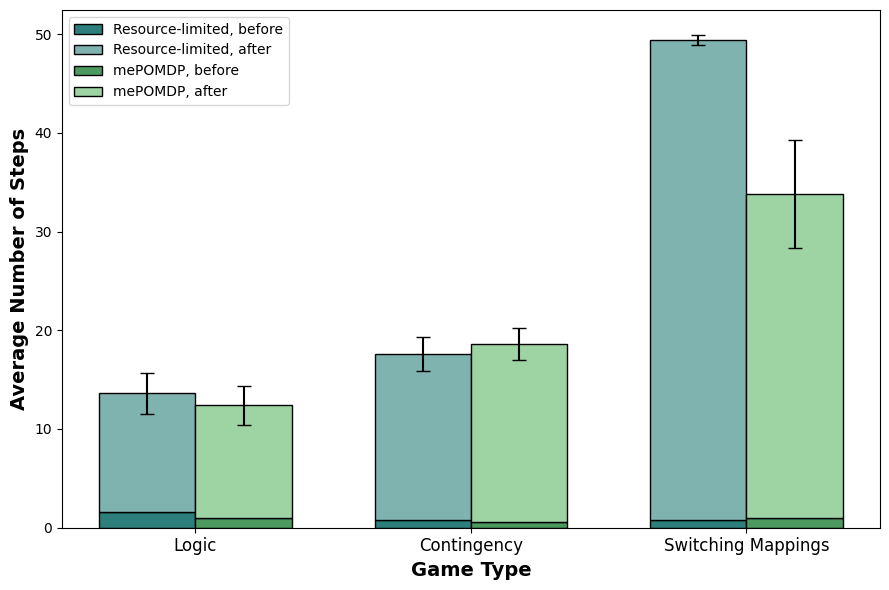

In [36]:
import numpy as np
import matplotlib.pyplot as plt

game_types = [
    'logic_u-v0',
    'contingency_u-v0',
    'changeAgent_u-7-v0'
]

game_labels = ['Logic', 'Contingency', 'Switching Mappings']

def safe_mean(x):
    x = [v for v in x if v is not None]
    return np.mean(x) if len(x) > 0 else 0

def sem(x):
    x = [v for v in x if v is not None]
    return np.std(x) / np.sqrt(len(x)) if len(x) > 0 else 0

avg_base_before = []
avg_base_after = []
avg_limited_before = []
avg_limited_after = []

sem_base_total = []
sem_limited_total = []

for g in game_types:

    base_before = results["base"][g]["before"]
    base_total  = results["base"][g]["total"]
    base_after  = [t - b for t, b in zip(base_total, base_before)]

    limited_before = results["limited"][g]["before"]
    limited_total  = results["limited"][g]["total"]
    limited_after  = [t - b for t, b in zip(limited_total, limited_before)]

    avg_base_before.append(safe_mean(base_before))
    avg_base_after.append(safe_mean(base_after))
    avg_limited_before.append(safe_mean(limited_before))
    avg_limited_after.append(safe_mean(limited_after))

    sem_base_total.append(sem(base_total))
    sem_limited_total.append(sem(limited_total))

x = np.arange(len(game_types))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 6))

# -------- Color families (close shades) --------
limited_dark = "#2C7F7B"
limited_light = "#7FB3B0"

base_dark = "#4C9A5F"
base_light = "#9ED3A3"

# ----- Limited agent stack -----
ax.bar(x - width/2, avg_limited_before, width,
       color=limited_dark,
       edgecolor='black',
       label='Resource-limited, before')

ax.bar(x - width/2, avg_limited_after, width,
       bottom=avg_limited_before,
       color=limited_light,
       edgecolor='black',
       label='Resource-limited, after')

# ----- Base agent stack -----
ax.bar(x + width/2, avg_base_before, width,
       color=base_dark,
       edgecolor='black',
       label='mePOMDP, before')

ax.bar(x + width/2, avg_base_after, width,
       bottom=avg_base_before,
       color=base_light,
       edgecolor='black',
       label='mePOMDP, after')

# ----- Error bars on total -----
limited_totals = np.array(avg_limited_before) + np.array(avg_limited_after)
base_totals = np.array(avg_base_before) + np.array(avg_base_after)

ax.errorbar(x - width/2, limited_totals,
            yerr=sem_limited_total,
            fmt='none', capsize=5, color='black')

ax.errorbar(x + width/2, base_totals,
            yerr=sem_base_total,
            fmt='none', capsize=5, color='black')

# ----- Labels -----
ax.set_xlabel("Game Type", fontsize=14, fontweight='bold')
ax.set_ylabel("Average Number of Steps", fontsize=14, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(game_labels, fontsize=12)

ax.legend()
plt.tight_layout()
plt.show()


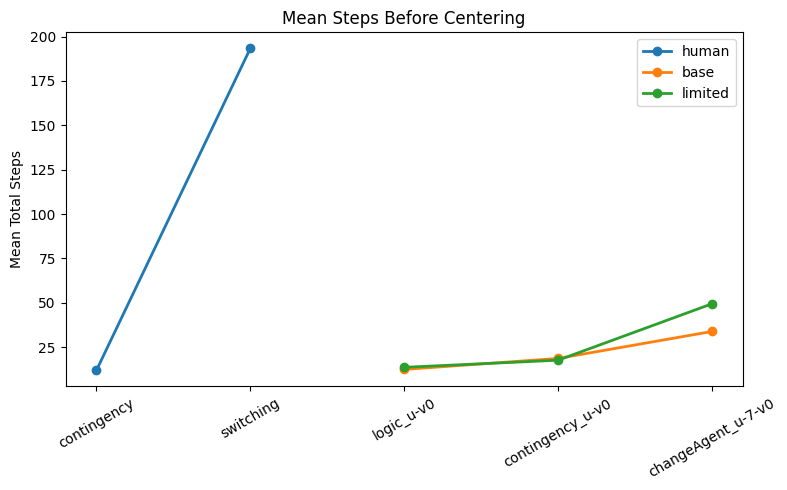

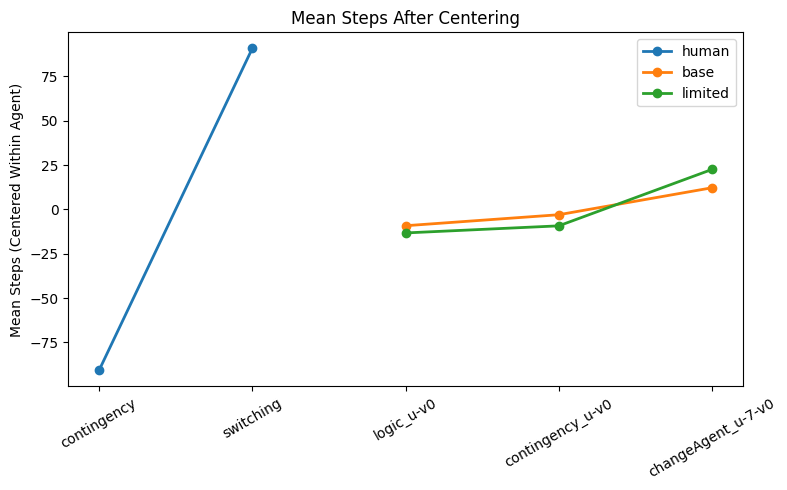

In [40]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

rows = []

#MODEL DATA
for agent in ["base", "limited"]:
    for game in results[agent].keys():

        mean_before = np.mean(results[agent][game]["before"])
        mean_after = np.mean(results[agent][game]["after"])
        mean_total = np.mean(results[agent][game]["total"])

        rows.append({
            "agent": agent,
            "game": game,
            "before": mean_before,
            "after": mean_after,
            "total": mean_total
        })

model_df = pd.DataFrame(rows)

#HUMAN DATA 
# Load human CSVs
logic = pd.read_csv("C:/Users/admin/Downloads/inferself-main/human_data/study1/data/centering/self_orienting_logic_game.csv")
contingency = pd.read_csv("C:/Users/admin/Downloads/inferself-main/human_data/study1/data/centering/self_orienting_contingency_game.csv")
switching = pd.read_csv("C:/Users/admin/Downloads/inferself-main/human_data/study1/data/centering/self_orienting_change_agent_game.csv")

logic["game"] = "logic"
contingency["game"] = "contingency"
switching["game"] = "switching"

human = pd.concat([logic, contingency, switching])

# Remove trials without centering
human = human.dropna(subset=["self_finding_steps"])

# Compute before / after
human["before"] = human["self_finding_steps"]
human["after"] = human["steps"] - human["self_finding_steps"]

# Compute means per game
human_df = (
    human.groupby("game")[["before", "after", "steps"]]
    .mean()
    .reset_index()
)

human_df = human_df.rename(columns={"steps": "total"})
human_df["agent"] = "human"


all_df = pd.concat([model_df, human_df], ignore_index=True)


all_df["total_centered"] = (
    all_df.groupby("agent")["total"]
    .transform(lambda x: x - x.mean())
)

plt.figure(figsize=(8,5))

for agent in ["human", "base", "limited"]:
    subset = all_df[all_df["agent"] == agent]
    plt.plot(
        subset["game"],
        subset["total"],
        marker="o",
        linewidth=2,
        label=agent
    )

plt.ylabel("Mean Total Steps")
plt.title("Mean Steps Before Centering")
plt.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))

for agent in ["human", "base", "limited"]:
    subset = all_df[all_df["agent"] == agent]
    plt.plot(
        subset["game"],
        subset["total_centered"],
        marker="o",
        linewidth=2,
        label=agent
    )

plt.ylabel("Mean Steps (Centered Within Agent)")
plt.title("Mean Steps After Centering")
plt.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()
